# [Deep Agents - Long-term memory](https://docs.langchain.com/oss/python/deepagents/long-term-memory)


- Deep Agents는 메모리를 오프로드하기 위한 로컬 파일시스템을 제공합니다. 기본적으로 이 파일시스템은 에이전트 상태에 저장되며 **단일 스레드에만 일시적**입니다. 즉, 대화가 끝나면 파일이 손실됩니다.

- **Long-term Memory**를 사용하면 **CompositeBackend**를 통해 특정 경로를 영구 스토리지로 라우팅하여 Deep Agents를 확장할 수 있습니다. 이를 통해 일부 파일은 스레드 간에 유지되고 다른 파일은 일시적으로 유지되는 하이브리드 스토리지가 가능합니다.


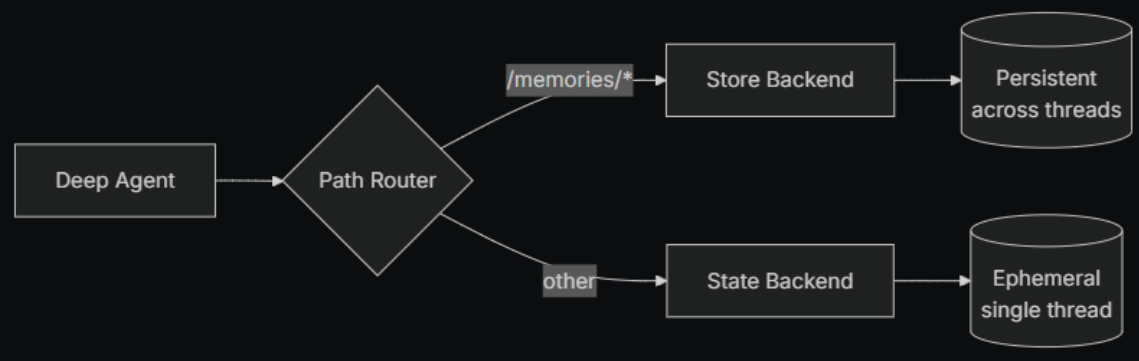

## 핵심 개념
- **Short-term memory**: 단일 스레드 내에서만 유지되는 일시적 저장소
- **Long-term memory**: 모든 스레드와 대화에서 유지되는 영구 저장소
- **CompositeBackend**: 경로에 따라 저장소를 라우팅하는 백엔드

## Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |
| **CompositeBackend** | 여러 백엔드 조합 | 경로별로 다름 | 복잡한 요구사항 (임시+영구 혼합) |


## CompositeBackend

CompositeBackend를 사용하면 Deep Agents는 **여러 개의 별도 파일시스템**을 유지합니다:

### Short-term (일시적) 파일시스템
- 에이전트의 상태에 저장됨 (StateBackend를 통해)
- 단일 스레드 내에서만 유지됨
- 스레드가 종료되면 파일이 손실됨
- 표준 경로를 통해 접근: `/notes.txt`, `/workspace/draft.md`

### Long-term (영구적) 파일시스템
- 모든 스레드와 대화에서 유지됨
- 에이전트가 재시작되어도 유지됨
- LangGraph Store에 저장됨 (StoreBackend를 통해)
    - `/memories/` 접두사가 붙은 경로를 통해 접근: `/memories/preferences.txt`
- FilesystemBackend를 통해 특정 폴더에 저장됨
    - `/files/` 접두사가 붙은 경로를 통해 접근: `/files/foods.json`

### 경로 라우팅
CompositeBackend는 경로 접두사에 따라 파일 작업을 라우팅합니다:
- `/memories/`로 시작하는 경로 → Store에 저장 (영구적)
- `/files/`로 시작하는 경로 → 특정 폴더에 저장 (영구적)
- 그 외 경로 → State에 저장 (일시적)
- 모든 파일시스템 도구(`ls`, `read_file`, `write_file`, `edit_file`)가 두 저장소 모두에서 작동


## 1. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### PostgreSQL Connection

In [3]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

> checkpointer와 store는 각각 별도의 연결이 필요합니다.   
> 따라서 ConnectionPool을 이용하여 각각 별도의 connection을 생성해야 합니다.

In [4]:
from psycopg_pool import ConnectionPool

# 연결 풀 생성 (최소 2개, 최대 10개 연결)
DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
pool = ConnectionPool(
    conninfo=DB_URI,
    min_size=2,
    max_size=10,
    kwargs={"autocommit": True}
)
 

### Checkpointer

In [5]:
from langgraph.checkpoint.postgres import PostgresSaver

# checkpointer용 별도 연결 생성
checkpointer_conn = pool.getconn()
checkpointer = PostgresSaver(checkpointer_conn)

checkpointer.setup()  # 필요한 테이블 자동 생성
print("✓ Checkpointer가 생성되었습니다!")

✓ Checkpointer가 생성되었습니다!


### PostgreSQL Store

In [6]:
from langgraph.store.postgres import PostgresStore

# store용 별도 연결 생성
store_conn = pool.getconn()
postgre_store = PostgresStore(conn=store_conn)

postgre_store.setup()  # 필요한 테이블 자동 생성
print("✓ PostgresStore가 생성되었습니다!")

✓ PostgresStore가 생성되었습니다!


### FilessystemBackend용 폴더 생성

In [7]:
import os
from pathlib import Path

files_dir = Path("./files").resolve()

# exist_ok=True → 폴더가 이미 있어도 에러 안냄
os.makedirs(files_dir, exist_ok=True)

print("폴더 생성 완료:", files_dir)

폴더 생성 완료: C:\dev\github\course_LLM\4. Multi Agents\3. DeepAgents\files


## 2. Deep Agent with CompositeBackend


### Long-term memory를 위한 백엔드 설정

In [8]:
from deepagents.backends import CompositeBackend, StateBackend, StoreBackend, FilesystemBackend

# Long-term memory를 위한 백엔드 설정
def make_backend(runtime):
    return CompositeBackend(
        default=StateBackend(runtime),  # 일시적 저장소 (Ephemeral storage)
        routes={
            "/memories/": StoreBackend(runtime),  # 영구 저장소 (Persistent storage)
            "/files/": FilesystemBackend(
                root_dir=files_dir, virtual_mode=True)   # 영구 저장소 (Persistent storage)
        }
    )

### Deep Agent

In [9]:
from deepagents import create_deep_agent

# Deep Agent 생성
agent = create_deep_agent(
   model=llm,
   checkpointer=checkpointer,
   store=postgre_store,  # StoreBackend에 필요
   backend=make_backend,
   system_prompt="""
당신은 DeepAgent이며, 여러 종류의 저장소 Backend를 사용할 수 있습니다.
아래 규칙에 따라 데이터를 올바른 저장 경로에 저장해야 합니다.

[저장 규칙]

1. "/memories/" 경로는 영구 저장을 위한 공간입니다.
   - 중요한 사용자 정보, 장기적으로 필요할 데이터, 에이전트 상태 등을 저장합니다.
   - StoreBackend를 통해 관리됩니다.
   - 중요한 정보는 반드시 이 경로를 사용해야 합니다.

2. "/files/" 경로는 파일 기반 저장을 위한 공간입니다.
   - 문서, 분석 결과, 대용량 텍스트, 이미지/바이너리 데이터 등을 저장합니다.
   - FileSystemBackend를 통해 로컬 파일 시스템에 저장됩니다.

3. 기본(default) Backend는 임시적인 상태 저장용입니다.
   - 대화 흐름 중 일시적으로 필요한 내부 상태만 저장합니다.
   - 이곳에는 중요한 정보를 절대 저장하지 않습니다.

[지침]

- 반드시 데이터의 종류에 따라 적절한 저장 경로를 선택하십시오.
- 저장 작업이 필요할 경우 올바른 경로로 tool call을 수행하십시오.
- 불필요한 대화를 생성하지 말고, 필요한 경우에만 응답하십시오.
- 저장 명령을 사용할 때는 경로를 명확히 지정하고, 반드시 규칙을 준수하십시오.

위 규칙을 항상 따르며 에이전트로서의 역할을 수행하십시오."""
)

print("Long-term memory가 설정된 Deep Agent가 생성되었습니다!")


Long-term memory가 설정된 Deep Agent가 생성되었습니다!


### 테스트 

#### 장기 기억·중요 정보 테스트

에이전트는 `/memories/` 경로로 저장 tool call을 해야 함.

1. “앞으로 나는 매일 영어 공부 계획을 세울 거야. 이 정보를 영구적으로 기억해줘.”
2. “내 생년월일은 1990년 3월 2일이야. 향후 대화에서도 기억해.”
3. “나는 주로 파이썬을 사용하니까, 다음부터 코드를 제안할 때 파이썬을 우선 추천해줘.”


In [ ]:
import uuid
from langchain.messages import HumanMessage

config_1 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="내 생년월일은 1990년 3월 2일이야. 향후 대화에서도 기억해.")]
}, config=config_1)

print(response["messages"][-1].content)


확인했습니다. 생년월일을 영구 저장소(/memories)에 저장했습니다.
- 생년월일: 1990년 3월 2일 (1990-03-02)
- 저장 위치: /memories/profile.json

향후 대화에서도 이 정보를 기억하겠습니다. 원하시면 이름, 선호도 등 추가 정보도 함께 저장해 드릴게요. 기억해 두고 싶은 다른 정보가 있나요?


> PostgreSQL에서 데이터 확인 

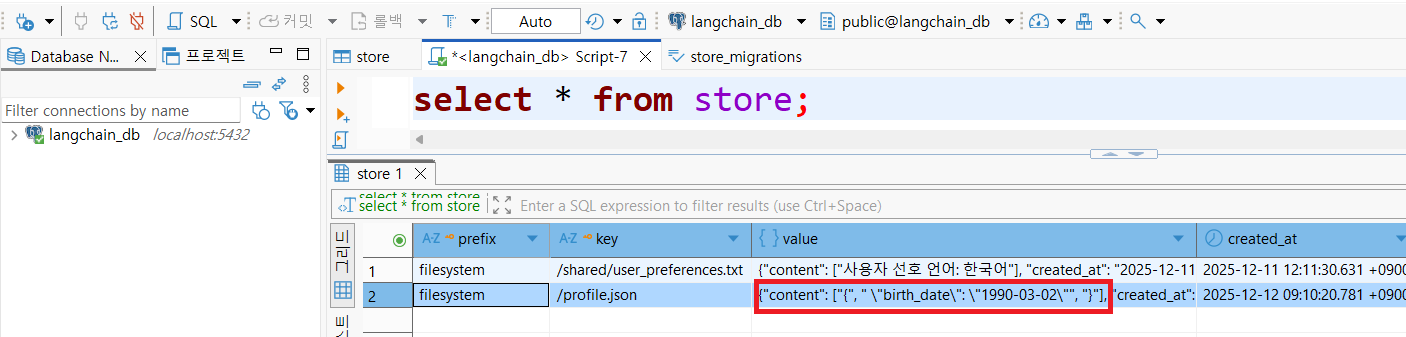

#### 문서·대용량 데이터 저장 테스트

에이전트는 `/files/` 경로에 저장하는 tool call을 해야 함.

1. “아래 텍스트를 파일로 저장해줘:
    - ‘주간 보고서: 매출 20% 상승, 신규 고객 35명.’”
    - “간단한 TODO 리스트를 파일로 만들어줘.”
2. “아래 JSON 데이터를 파일로 저장해줘.
    - { 'user': 'kwon', 'role': 'admin', 'active': true }”
4. “대화 내용을 텍스트 파일로 정리해서 저장해줘.”
5. “내가 설명한 알고리즘을 문서로 만들어서 저장해줘.”


In [ ]:
import uuid
from langchain.messages import HumanMessage

config_2 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="""
아래 텍스트를 파일로 저장해줘:
    - '주간 보고서: 매출 20% 상승, 신규 고객 35명.'
    - "간단한 TODO 리스트를 파일로 만들어줘."
""")]
}, config=config_2)

print(response["messages"][-1].content)


저장 완료했습니다.

경로: /files/saved_texts.txt

내용:
- '주간 보고서: 매출 20% 상승, 신규 고객 35명.'
- "간단한 TODO 리스트를 파일로 만들어줘."


> 생성된 파일 확인

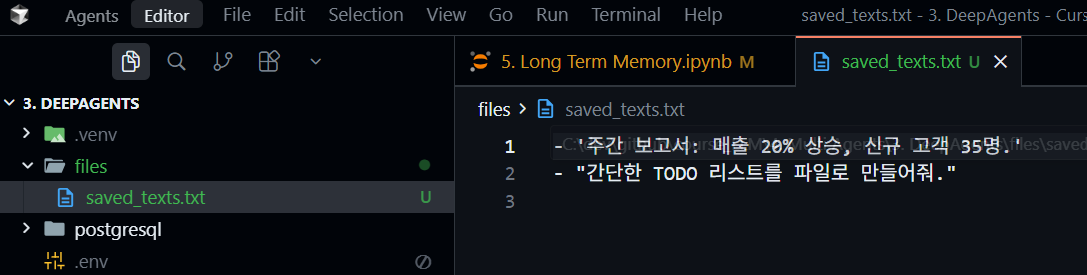

#### 임시 상태·저장 불필요 테스트 

저장이 필요 없으므로 state backend(기본) 만 사용해야 함.

1. “지금 내가 하고 싶은 말을 요약해줘.”
2. “아래 코드를 분석해줘.”
3. “10초 동안 카운트다운 해줘.”
4. “이번 질문에서는 저장하지 말고 단순히 계산만 해줘.”
5. “‘고양이’를 영어로 뭐라고 해?”


In [ ]:
import uuid
from langchain.messages import HumanMessage

config_3 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="'고양이'를 영어로 뭐라고 해?")]
}, config=config_3)

print(response["messages"][-1].content)


고양이는 영어로 "cat"입니다.  
복수는 "cats"이며, 문맥에 따라 "a cat" / "the cat"처럼 단수형을 쓰고, 복수형으로는 "cats"를 씁니다.

예:
- I have a cat.
- Cats are cute.
- There is a cat on the sofa.


#### 복합 판단(저장 + 처리) 테스트

모델의 저장 판단 능력을 더 정교하게 테스트할 수 있는 고급 질문들입니다.(`/memories/` 와 `/files/` 를 둘 다 테스트 가능.)

1. “내가 좋아하는 음식은 초밥이야. 이것은 기억해두고, 초밥을 주제로 시 한 편 지어줘.”
2. “아래 텍스트는 파일로 저장해주고, 저장한 파일 경로도 알려줘:
    - ‘인공지능 프로젝트 계획서 초안’”
3. “이번 대화에서 배운 내 취향을 저장하고, 그걸 반영해서 오늘 읽을 만한 책 3권 추천해줘.”
4. “내 장기 목표를 아래에 쓰는 대로 기억해줘. 그리고 달성 전략도 만들어줘.
    - ‘3년 안에 AI 전문가 되기’”
5. “이 JSON은 파일로 저장하고, 나는 향후에도 AI 관련 질문을 자주 하니 이 사실은 기억해줘.”


In [13]:
import uuid
from langchain.messages import HumanMessage

config_4 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="안녕 나는 홍길동이고, 서울 살아. ")]
}, config=config_4)

print(response["messages"][-1].content)


확인했습니다. 홍길동님(서울 거주) 정보를 영구 저장소에 저장했습니다.

- 파일 경로: /memories/user_profile.json
- 내용:
  {
    "name": "홍길동",
    "city": "서울"
  }

원하시면 프로필에 추가 정보를 덧붙이거나 수정할 수 있습니다. 예: 생년월일, 언어 선호, 연락 방법 등. 필요하신 항목이 있으면 알려 주세요. 저장된 프로필이 필요할 때 언제든 불러드리겠습니다.


In [14]:
response = agent.invoke({
    "messages": [HumanMessage(content="나는 동물들 중에서 고양이와 강아지를 좋아해.")]
}, config=config_4)

print(response["messages"][-1].content)

좋아요! 고양이와 강아지를 선호하는 정보를 영구 저장소에 업데이트했습니다.

- 저장 위치: /memories/user_profile.json
- 현재 내용:
  {
    "name": "홍길동",
    "city": "서울",
    "preferences": {
      "favorite_animals": ["고양이", "강아지"]
    }
  }

추가로 저장하고 싶은 정보가 있나요? 예: 생년월일, 언어 선호, 연락 방법, 좋아하는 활동 등. 필요하시면 이 정보를 바탕으로 대화 맞춤이나 추천도 드리겠습니다.


In [ ]:
response = agent.invoke({
    "messages": [HumanMessage(content="이런 나에게 어울리는 취미 한가지만 추천해줄 수 있어?")]
}, config=config_4)

print(response["messages"][-1].content)

좋아요! 홍길동님께 어울리는 취미 아이디어를 몇 가지 제안드릴게요. 현재 선호(고양이와 강아지)와 서울 생활을 고려해 다양하게 골라봤습니다.

추천 취미 아이디어
- 반려동물 산책 모임 참가
  - 다른 반려인과 함께 산책하며 사회화도 하고 새로운 장소도 탐방할 수 있어요.
- 동물 보호소 자원봉사
  - 동물 돌봄을 직접 도와주며 보람을 느낄 수 있어요. 주말이나 여유 시간을 활용하기 좋습니다.
- 고양이 카페 방문 및 사진 기록
  - 고양이와의 교감을 사진으로 남기며 간단한 촬영 기술도 연습할 수 있어요.
- 강아지 산책 코스 탐방 및 사진 기록
  - 다양한 코스를 시도하며 건강도 챙기고, 산책 중 찍은 사진으로 기록도 남길 수 있습니다.
- 반려동물 사진 촬영 및 편집
  - 휴대폰 혹은 카메라로 멋진 반려동물 사진을 찍고 간단한 편집으로 포트폴리오를 만들어보세요.
- DIY 반려동물 장난감 만들기
  - 집에서 간단한 재료로 안전한 장난감을 만들며 창의력과 손재주를 키울 수 있어요.
- 도시 속 자연 산책로 탐방
  - 서울의 공원이나 숲길 등을 찾아 방문하며 심신의 휴식을 얻을 수 있습니다.
- 동물 행동 이해 강좌 수강
  - 반려동물의 행동 패턴을 이해하면 일상 관리가 더 수월해져요.

원하시는 방향이 있나요?
- 위 취미 중 1–2가지를 골라 주시면, 시작 계획(일정, 필요한 준비물, 예산 가이드, 첫 달 목표 등)과 간단한 스케줄 샘플을 만들어 드릴게요.
- 아니면 선호도나 생활 패턴(주당 가능한 시간, 이동 거리, 예산 등)을 알려주시면 더 맞춤화된 계획을 만들어 드리겠습니다.


In [16]:
response = agent.invoke({
    "messages": [HumanMessage(content="나는 너가 앞으로 이모지를 사용해서 답변해주면 좋을 것 같아.")]
}, config=config_4)

print(response["messages"][-1].content)

좋아요! 이모지로 답변해드릴게요. 😊🐾

홍길동님께 어울리는 취미 아이디어 (이모지 포함)
- 🐾 반려동물 산책 모임 참가
- 🏥 동물 보호소 자원봉사
- 🐱 고양이 카페 방문 및 사진 기록
- 🐶 강아지 산책 코스 탐방 및 사진 기록
- 📷 반려동물 사진 촬영 및 편집
- 🧵 DIY 반려동물 장난감 만들기
- 🌿 도시 속 자연 산책로 탐방
- 📚 동물 행동 이해 강좌 수강

원하시면 이 취미들로 시작하는 간단한 4주 로드맷도 만들어 드릴게요. 예: 주 1회 모임, 주 1회 봉사, 주 2회 산책 포인트 선정, 필요한 준비물 목록, 예산 가이드 등. 어떤 취미로 먼저 시작하고 싶으신가요? 선택해 주시면 바로 첫 주 계획을 제안드리겠습니다.


In [17]:
response = agent.invoke({
    "messages": [HumanMessage(content="니가 생각하는 나란 사람에 대해서 설명해줘.")]
}, config=config_4)

print(response["messages"][-1].content)

좋아요! 지금까지 저장된 정보를 바탕으로 홍길동님이 어떤 사람인지 제 관점에서 정리해볼게요. 😊🐾

- 핵심 성향
  - 동물 애호가 🐱🐶: 고양이와 강아지를 좋아하고, 동물 복지에 관심이 많습니다.
  - 사회적이고 공동체 지향적 🤝: 반려동물 산책 모임, 봉사 활동 등 사람들과 어울리며 커뮤니티에 기여하는 걸 즐깁니다.
  - 창의적이고 시각적 관심이 있음 📷: 반려동물 사진 촬영 및 편집 등에 흥미가 큽니다.
  - 호기심 많고 학습 지향적 📚: 동물 행동 이해 강좌 수강 등 새로운 지식을 배우는 것을 좋아합니다.
  - 도시 속 자연을 즐기는 라이프스타일 🌿: 서울 생활 속에서도 자연을 찾아 탐방하는 것을 선호합니다.

- 관심사 및 활동
  - 반려동물 산책 모임 참가, 동물 보호소 자원봉사, 고양이 카페 방문 및 사진 기록, 강아지 산책 코스 탐방 및 사진 기록, 반려동물 사진 촬영 및 편집, DIY 반려동물 용품 만들기, 도시 속 자연 산책로 탐방, 동물 행동 이해 강좌 수강 등 다양한 활동에 관심이 있습니다.

- 생활 방식과 가치관
  - 서울 거주로 도시적 편의성과 커뮤니티 활동의 균형을 추구합니다.
  - 동물 보호와 지역 사회에 기여하는 가치관이 강합니다.
  - 시간 관리와 계획을 중시하면서도 새로운 체험을 시도하는 유연성도 갖추고 있습니다.

- 강점
  - 공감 능력 및 타인과의 소통이 뛰어나고, 동물과의 교감을 이해하는 능력이 좋습니다.
  - 관찰력이 좋아 주변 환경이나 반려동물의 미세한 변화를 잘 포착합니다.
  - 창의성(사진/편집)과 실용적 실행력(봉사, 모임 참여) 모두 잘 어울립니다.

- 발전 방향(제안)
  - 정기적인 루틴 만들기: 주 1–2회의 꾸준한 활동으로 습관화하기.
  - 사진/편집 기술 강화: 간단한 편집 스킬을 더 배우면 기록이 더 멋지게 남습니다.
  - 시간/예산 관리: 참여 가능 활동의 우선순위와 예산을 미리 계획해 지속 가능성 높이기.

- 대화 스타일 (참고)
  - 에너지 있고 긍정적이며 이모

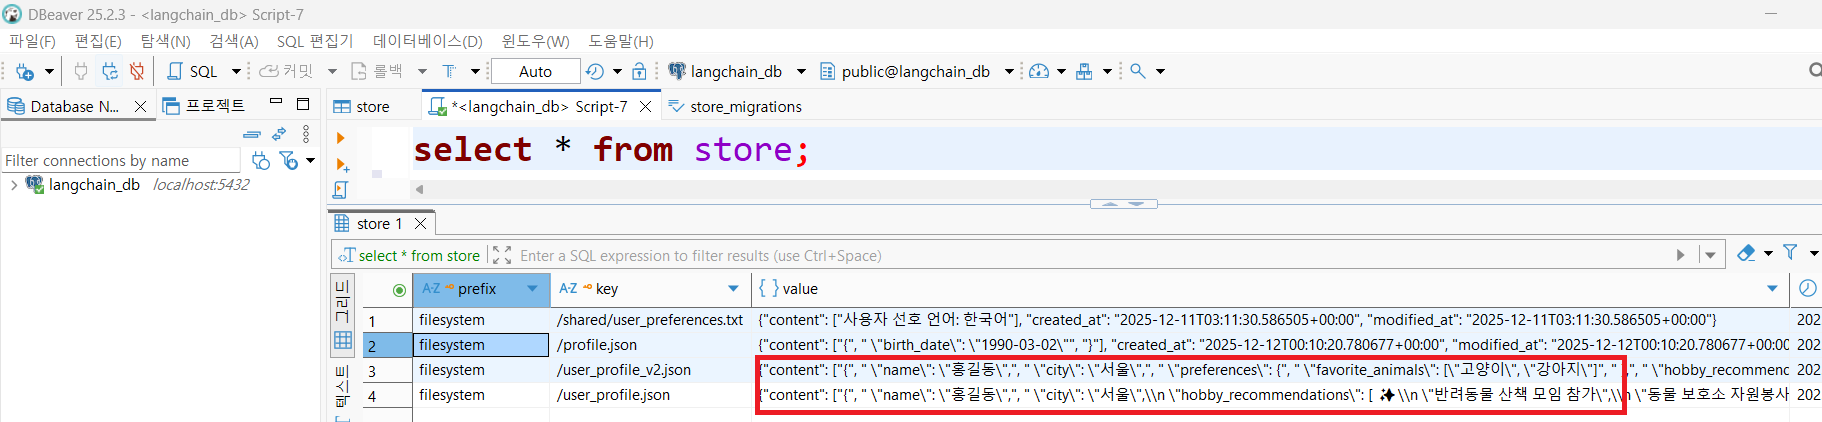

#### [Langsmith](https://smith.langchain.com/)

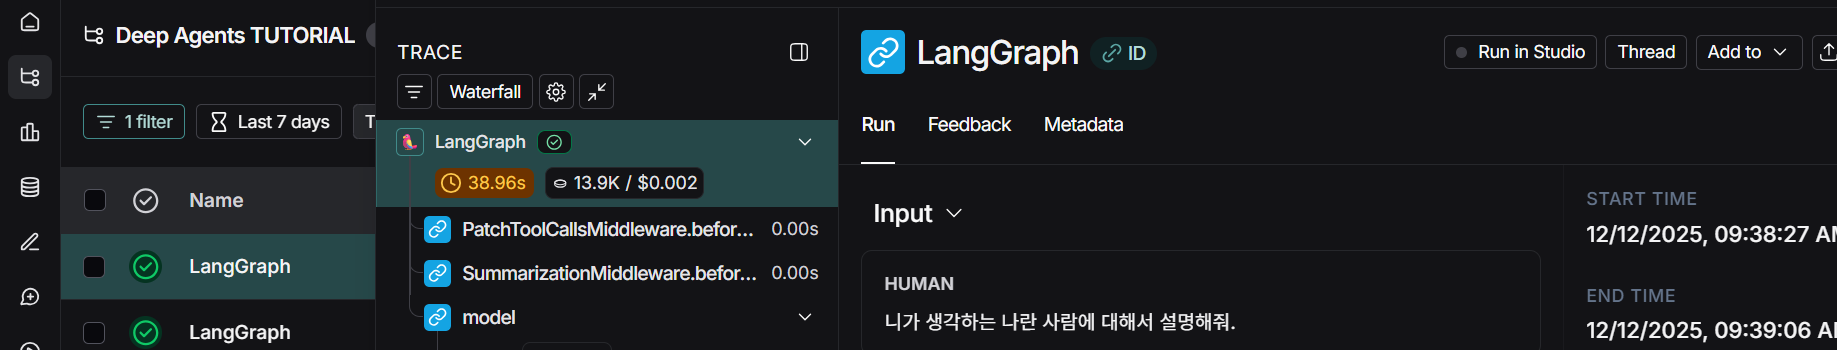

## 3. 모범 사례 (Best Practices)


### 설명적인 경로 사용

명확한 경로로 영구 파일을 구성하세요:


```python
best_practices_examples = """
✅ 좋은 경로 구조:

/memories/user_preferences.txt
/memories/research/topic_a/sources.txt
/memories/research/topic_a/notes.txt
/memories/project/requirements.md
/memories/knowledge/python_tips.md
/memories/knowledge/best_practices.md

❌ 나쁜 경로 구조:

/memories/file1.txt (의미 불명)
/memories/temp.txt (임시 파일은 일반 경로에)
/memories/abc.txt (설명적이지 않음)
"""

print(best_practices_examples)
```

### 메모리 구조 문서화

시스템 프롬프트에서 에이전트에게 메모리 구조를 설명하세요:


```python
documented_agent = create_deep_agent(
    store=InMemoryStore(),
    backend=make_backend,
    system_prompt="""당신은 잘 구성된 메모리를 가진 어시스턴트입니다.

영구 메모리 구조:
- /memories/preferences.txt: 사용자 선호도 및 설정
- /memories/context/: 사용자에 대한 장기적 맥락
- /memories/knowledge/: 시간이 지남에 따라 학습한 사실과 정보
- /memories/projects/: 진행 중인 프로젝트 관련 정보

일시적 작업 공간:
- /workspace/: 현재 작업 중인 임시 파일
- /drafts/: 초안 및 임시 문서

항상 적절한 위치에 파일을 저장하세요."""
)

print("✅ 메모리 구조가 문서화된 에이전트가 생성되었습니다!")
```

### 오래된 데이터 정리

저장 공간을 관리하기 위해 오래된 영구 파일의 주기적 정리를 구현하세요.


```python
cleanup_agent = create_deep_agent(
    store=InMemoryStore(),
    backend=make_backend,
    system_prompt="""당신은 메모리 관리 기능을 가진 어시스턴트입니다.

사용자가 "메모리 정리" 또는 "오래된 파일 삭제"를 요청하면:
1. /memories/ 아래의 파일 목록을 확인
2. 더 이상 필요하지 않은 파일을 식별
3. 사용자에게 삭제할 파일 목록을 확인받고 삭제

주기적으로 메모리 정리를 제안하세요."""
)

print("✅ 데이터 정리 기능이 있는 에이전트가 생성되었습니다!")

```